# Carte des prix au m² par commune - Ille-et-Vilaine

Ce notebook construit une carte choroplèthe des prix médians au m² par commune, en croisant le jeu de données DVF nettoyé avec les contours géographiques des communes d'Ille-et-Vilaine.

Source des contours : [france-geojson](https://github.com/gregoiredavid/france-geojson) (tracés IGN/INSEE), fichier `communes_35.geojson`.

## Sommaire

1. [Chargement des données](#section-1)
2. [Préparation de la jointure](#section-2)
3. [Statistiques et fiabilité par commune](#section-3)
4. [Jointure avec les contours géographiques](#section-4)
5. [Construction de la carte](#section-5)

<a id="section-1"></a>

## 1. Chargement des données

In [1]:
# Bibliothèques utilisées dans ce notebook : pandas pour les données
# tabulaires, geopandas pour les données géographiques, matplotlib pour
# le dessin de la carte
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/dvf_35_nettoye.csv")
communes = gpd.read_file("../maps/communes_35.geojson")

print(df.shape)
print(communes.shape)
communes.head()

(76419, 11)
(345, 3)


,code,nom,geometry
0,35013,Bains-sur-Oust,"POLYGON ((-2.10385 47.67619, -2.10519 47.67712..."
1,35064,Chapelle-de-Brain,"POLYGON ((-1.95633 47.67119, -1.96124 47.67092..."
2,35145,Langon,"POLYGON ((-1.88493 47.69601, -1.88526 47.69772..."
3,35237,Renac,"POLYGON ((-2.01664 47.72195, -2.02709 47.72337..."
4,35268,Saint-Ganton,"POLYGON ((-1.90972 47.75369, -1.91016 47.75489..."


**Résultat :** 76 419 ventes DVF, et 345 communes dans le fichier géographique (contre 333 dans le DVF : 12 communes du département n'ont eu aucune vente de maison ou d'appartement sur 2021-2025 dans le périmètre retenu). Le `GeoDataFrame` contient une colonne `geometry` supplémentaire par rapport à un DataFrame classique, qui stocke le contour de chaque commune.

<a id="section-2"></a>

## 2. Préparation de la jointure

Avant de croiser les deux tableaux, il faut vérifier que leurs codes commune sont bien dans le même format : une jointure entre un type texte et un type numérique échouerait silencieusement, sans erreur explicite.

In [2]:
# Vérification des types du code commune de chaque côté
print(df["code_commune"].dtype)
print(communes["code"].dtype)

int64
str


**Résultat :** `code_commune` est en `int64` côté DVF, `code` est en texte côté fichier géographique. Conversion nécessaire avant la jointure.

In [3]:
# Conversion du code commune du DVF en texte, pour qu'il corresponde
# au format du fichier géographique
df["code_commune"] = df["code_commune"].astype(str)

print(df["code_commune"].dtype)
print(df["code_commune"].head())

str
0    35238
1    35051
2    35281
3    35281
4    35238
Name: code_commune, dtype: str


<a id="section-3"></a>

## 3. Statistiques et fiabilité par commune

Toutes les communes n'ont pas le même nombre de ventes : un prix médian calculé sur trop peu de transactions serait peu fiable. Plutôt que d'exclure les communes les moins représentées comme pour le classement top/flop de l'analyse exploratoire, on les garde ici mais on les identifie avec un indicateur, pour que la carte reste complète sans donner une fausse impression de précision.

In [4]:
# Prix médian et nombre de ventes par commune, puis indicateur de
# fiabilité basé sur le même seuil que le classement top/flop (30
# ventes minimum)
stats_par_commune = df.groupby("code_commune").agg(
    prix_median=("prix_m2", "median"),
    nb_ventes=("prix_m2", "count")
).reset_index()

stats_par_commune["fiable"] = stats_par_commune["nb_ventes"] >= 30

print(stats_par_commune.shape)
stats_par_commune.head()

(333, 4)


,code_commune,prix_median,nb_ventes,fiable
0,35001,3053.110784,349,True
1,35002,2255.767081,90,True
2,35003,2222.639917,48,True
3,35004,1217.866115,364,True
4,35005,1459.219858,20,False


<a id="section-4"></a>

## 4. Jointure avec les contours géographiques

In [5]:
# Jointure gauche : on garde toutes les communes du fichier
# géographique, même celles sans aucune vente DVF, pour que la carte
# n'ait pas de trou
carte = communes.merge(stats_par_commune, left_on="code", right_on="code_commune", how="left")

print(carte.shape)
carte.head()

(345, 7)


,code,nom,geometry,code_commune,prix_median,nb_ventes,fiable
0,35013,Bains-sur-Oust,"POLYGON ((-2.10385 47.67619, -2.10519 47.67712...",35013,1730.303030,250.0,True
1,35064,Chapelle-de-Brain,"POLYGON ((-1.95633 47.67119, -1.96124 47.67092...",35064,1270.104315,144.0,True
2,35145,Langon,"POLYGON ((-1.88493 47.69601, -1.88526 47.69772...",35145,1338.235294,145.0,True
3,35237,Renac,"POLYGON ((-2.01664 47.72195, -2.02709 47.72337...",35237,1300.322061,82.0,True
4,35268,Saint-Ganton,"POLYGON ((-1.90972 47.75369, -1.91016 47.75489...",35268,1159.420290,33.0,True


**Résultat :** 345 lignes, comme attendu (toutes les communes du fichier géographique conservées).

In [6]:
# Les communes sans aucune vente DVF ont "fiable" à vide (NaN) après
# la jointure : on les traite comme non fiables, et on force le type
# booléen strict (nécessaire pour l'inversion ~ utilisée plus loin)
carte["fiable"] = carte["fiable"].fillna(False)
carte["fiable"] = carte["fiable"].astype(bool)

carte["fiable"].value_counts()

fiable
True     300
False     45
Name: count, dtype: int64

**Résultat :** 300 communes fiables, 45 non fiables (33 avec moins de 30 ventes, 12 sans aucune vente), cohérent avec le seuil déjà utilisé dans l'analyse exploratoire.

<a id="section-5"></a>

## 5. Construction de la carte

Les communes fiables sont colorées selon leur prix médian, les communes non fiables sont affichées en gris hachuré plutôt que cachées, pour signaler visuellement une donnée moins solide sans créer de trou sur la carte.

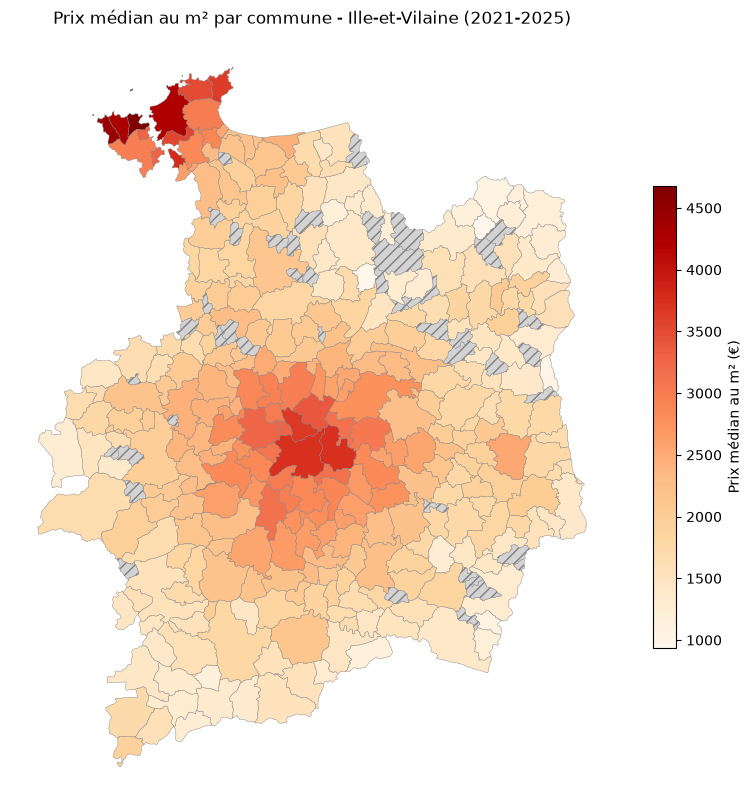

In [7]:
# Deux couches superposées sur les mêmes axes : le dégradé de couleur
# pour les communes fiables, le gris hachuré pour les autres
fig, ax = plt.subplots(figsize=(10, 10))

carte[carte["fiable"]].plot(
    column="prix_median",
    cmap="OrRd",
    linewidth=0.3,
    edgecolor="grey",
    legend=True,
    legend_kwds={"label": "Prix médian au m² (€)", "shrink": 0.6},
    ax=ax
)

carte[~carte["fiable"]].plot(
    color="lightgrey",
    hatch="///",
    linewidth=0.3,
    edgecolor="grey",
    ax=ax
)

ax.set_title("Prix médian au m² par commune - Ille-et-Vilaine (2021-2025)")
ax.axis("off")

plt.savefig("../screenshots/03_carte_prix_par_commune.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion :** la carte confirme visuellement les résultats de l'analyse exploratoire. Deux pôles de prix élevés se détachent nettement : la Côte d'Émeraude au nord-ouest (Dinard, Saint-Malo et leurs environs) et Rennes avec sa première couronne au centre du département. Le prix décroît progressivement à mesure qu'on s'éloigne de ces deux pôles vers les marges du département. Les communes non fiables (hachurées) sont dispersées principalement en périphérie, là où le volume de transactions est naturellement plus faible.